# Concepts

| Term                         | Meaning                    | What It Tells You                            |
| ---------------------------- | -------------------------- | -------------------------------------------- |
| **Mean**                     | Average value              | Central tendency of data                     |
| **Median**                   | Middle value               | Balance point, less affected by outliers     |
| **Mode**                     | Most frequent value        | Common or popular category/value             |
| **Standard Deviation (std)** | Average distance from mean | Spread or consistency of data                |
| **Variance**                 | Square of std              | How much data points differ from average     |
| **Skewness**                 | Measure of asymmetry       | Whether data is left or right-skewed         |
| **Kurtosis**                 | Measure of peakness        | Whether distribution is flat or heavy-tailed |


## Step 1 - Import Libraries and Load Data

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_name = r"C:\Users\hp\OneDrive\Documents\Data Analysis and Visualization Expertise\Extracted_Files\5-Days-Live-EDA-and-Feature-Engineering-main\Zomato_Dataset\zomato.csv"
df = pd.read_csv(file_name, encoding="latin1")

## By default, the encoding is "utf-8" which is mostly used for files from google sheets, kaggle, etc. 
If the encoding is "utf-8", no need to mention the encoding part.
But if the encoding is not "utf-8", we have to mention the encoding="latin1" or correct encoding.
This ensures it doesn't throw an UnicodeDecodeError.

latin1 (ISO-8859-1) — common for European text

cp1252 — common for Windows systems

utf-16 — used by Excel sometimes

So pandas doesn’t know how to interpret those bytes properly.
                                  

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Step 2 - Quick Overview using describe() - Automatically shows count, mean, std, min, max, and quartiles(25%, 50%, 75%,...)

In [5]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## Step 3 - Calculate Mean, Median, Mode manually

In mode, iloc[0] is used to select the first value that has the highest number of counts. 
If we don't use iloc[0], its fine if one value has maximum counts.
But if more than one value has same counts, it will print a Series, 
which can cause problems if wanted to store it in a variable or expecting a single number.

In mean and median, iloc[0] isn't required as they print a single float number 

In [6]:
mean_value = df.mean(numeric_only=True)
print("Mean: \n",mean_value)

median_value = df.median(numeric_only=True)
print("\nMedian: \n",median_value)

mode_value = df.mode(numeric_only=True).iloc[0]
print("\nMode: \n",mode_value)

Mean: 
 Restaurant ID           9.051128e+06
Country Code            1.836562e+01
Longitude               6.412657e+01
Latitude                2.585438e+01
Average Cost for two    1.199211e+03
Price range             1.804837e+00
Aggregate rating        2.666370e+00
Votes                   1.569097e+02
dtype: float64

Median: 
 Restaurant ID           6.004089e+06
Country Code            1.000000e+00
Longitude               7.719196e+01
Latitude                2.857047e+01
Average Cost for two    4.000000e+02
Price range             2.000000e+00
Aggregate rating        3.200000e+00
Votes                   3.100000e+01
dtype: float64

Mode: 
 Restaurant ID            53.0
Country Code              1.0
Longitude                 0.0
Latitude                  0.0
Average Cost for two    500.0
Price range               1.0
Aggregate rating          0.0
Votes                     0.0
Name: 0, dtype: float64


## Step 4 - Variance and Standard Deviation

In [7]:
variance_values = df.var(numeric_only=True)
print("Variance:\n",variance_values)

std_values = df.std(numeric_only=True)
print("\nStandard Deviation:\n",std_values)

Variance:
 Restaurant ID           7.729085e+13
Country Code            3.220624e+03
Longitude               1.719517e+03
Latitude                1.211746e+02
Average Cost for two    2.598925e+08
Price range             8.201274e-01
Aggregate rating        2.299401e+00
Votes                   1.850455e+05
dtype: float64

Standard Deviation:
 Restaurant ID           8.791521e+06
Country Code            5.675055e+01
Longitude               4.146706e+01
Latitude                1.100794e+01
Average Cost for two    1.612118e+04
Price range             9.056088e-01
Aggregate rating        1.516378e+00
Votes                   4.301691e+02
dtype: float64


## Step 5 - Skewness and Kurtosis

In [8]:
skew_values = df.skew(numeric_only=True)
print("Skewness:\n",skew_values)

kurtosis_values = df.kurt(numeric_only=True)
print("\nKurtosis:\n",kurtosis_values)

Skewness:
 Restaurant ID            0.061570
Country Code             3.043965
Longitude               -2.807328
Latitude                -3.081635
Average Cost for two    35.477915
Price range              0.889618
Aggregate rating        -0.954130
Votes                    8.807637
dtype: float64

Kurtosis:
 Restaurant ID             -1.950996
Country Code               7.392578
Longitude                  8.216586
Latitude                  12.530803
Average Cost for two    1495.777394
Price range               -0.142550
Aggregate rating          -0.582217
Votes                    128.225969
dtype: float64


## Step 6 - Example on a single column (if the dataset has ratings or cost)

errors = "coerce" is used to replace non-numeric values with missing values, NaN.

errors="raise" (default) - Throws an error if it finds any non-numeric value
errors="ignore"          - Leaves all values as they are (no conversion happens)

For doing calculations like mean, median, mode, std, variance, etc., all values must be converted to numeric.

In [10]:
df['Aggregate rating'] = pd.to_numeric(df['Aggregate rating'],errors="coerce") # convert to numeric
print(f"Mean Rating: {df['Aggregate rating'].mean():.1f}\n")
print(f"Median Rating: {df['Aggregate rating'].median():.1f}\n")
print(f"\nStandard Deviation: {df['Aggregate rating'].std():.1f}")

Mean Rating: 2.7

Median Rating: 3.2


Standard Deviation: 1.5


## Step 7 - Visualization

## Histogram - Shows Distribution Shape

## bins = n
 The data is divided into n equal-width intervals called bins.
 Each bin represents a range of values.
 The height of each bar shows how many values fall in that range.

If bins=10, broader ranges, fewer bars
if bins=50, narrower ranges, more detailed bars

So, bins decide how smooth or coarse the resulting histogram looks

## kde (Kernel Density Estimate)
    When kde=True, Seaborn adds a smooth curve over the histogram.
    This curve represents the probability density (smoothed version of histogram) that helps us see the overall shape of the data (normal,skewed,etc.)

## sns.histplot(df['Aggregate rating'], bins=20, kde=True) means: 
    “Plot a histogram of restaurant ratings with 20 bars, and overlay a smooth density curve showing the shape of the distribution.”
    

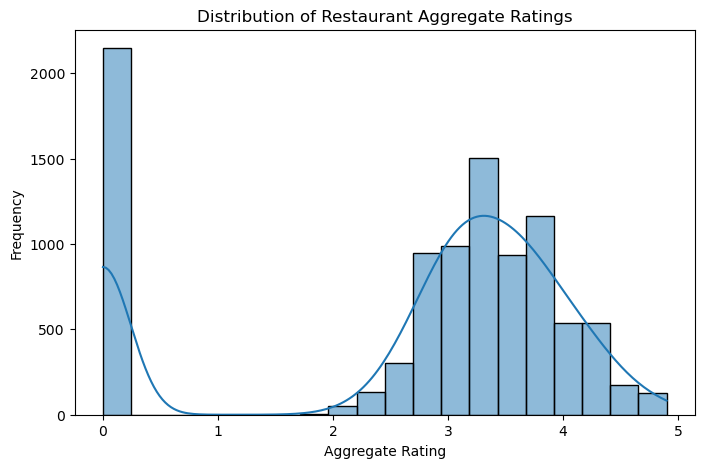

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title('Distribution of Restaurant Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

## Rules to pick good number of bins.

# 1. Square Root Rule

bins = n**0.5

Where n = number of data points.
✅ Simple, works reasonably well for most distributions.

In [11]:
n = len(df['Aggregate rating'])
bins = int(n**0.5)
print(f"Aggregate Ratings: {n}\n")
print(f"No. of bins: {bins}")

Aggregate Ratings: 9551

No. of bins: 97


# 2. Sturges' Rule

bins = 1 + log (base 2) n

Best for smaller datasets with roughly normal distribution.

In [14]:
import numpy as np
n = len(df['Aggregate rating'])
print(f"Aggregate Rating: {n}\n")
bins = int(1 + np.log2(n)) # Without int, the no. of bins was a floating point number.
print(f"No. of bins: {bins}")

Aggregate Rating: 9551

No. of bins: 14


# 3. Freedman-Diaconis Rule

bins = (max-min)/bin width
where bin width = (2*IQR)/n**(1/3)

Adapts to both sample size and data spread (robust for skewed data).
Best when data is not normally distributed (income,prices,etc.).

In [17]:
import numpy as np

data = df['Aggregate rating'].dropna()
n = len(data)
IQR = data.quantile(0.75) - data.quantile(0.25)
bin_width = (2*IQR)/(n**(1/3))
bins = int((data.max() - data.min())/bin_width)

print(f"Aggregate Rating: {n}")
print(f"\nIQR: {IQR:.2f}")
print(f"\nbin width: {bin_width:.2f}")
print(f"\nNo. of Bins: {bins}")

Aggregate Rating: 9551

IQR: 1.20

bin width: 0.11

No. of Bins: 43


## Boxplot - Shows Median, Quartiles and Outliers

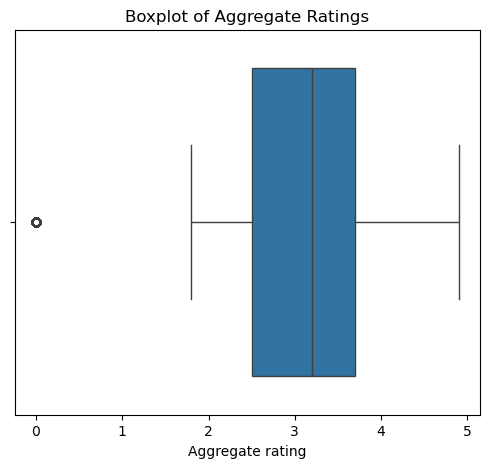

In [8]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['Aggregate rating'])
plt.title('Boxplot of Aggregate Ratings')
plt.show()